In [1]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from utils.help_function import *
from models.modelClassGPU import ConfiModel 

work_path = "M:/1confiProj/"
os.chdir(work_path)

device is : cpu


### Model Compare (AIC)

In [2]:
# for all models and all subjects, concat a big df
#sub_lst = [2, 3, 5, 6]
m_lst = np.arange(1, 9)
df_all = pd.DataFrame()
for sub_id in sub_lst:
    for m_id in m_lst:
        res_file_name = os.path.join(fit_res_path, 'model_' + str(m_id),  'fitted_sub_' + str(sub_id) + '_m' + str(m_id) + 
              '_bads.pkl')
        df_est = pd.read_pickle(res_file_name)
        df_all = pd.concat([df_all, df_est], ignore_index = True)

In [3]:
df_all.loc[:, 'k'] = df_all.loc[:, 'est_params'].apply(lambda x: len(x))
df_all.loc[:,'aic'] = 2 * df_all.loc[:,'k'] + df_all.loc[:,'nll']
df_all.head()

,run_id,model_id,sub_id,nll,est_params,init_params,runtime,success,k,aic
0,20250802_105724,1,2,17861.962292,"[1.1481545731093432, 6.690582275390625, 5.6307...","[0.7650932362060945, 2.766898032820359, 8.8813...",50.221650,True,13,17887.962292
1,20250802_114812,1,2,18184.109493,"[1.483817153657072, 8.935301959514618, 7.66442...","[1.3296850001002396, 3.5878313710309726, 12.17...",50.783473,True,13,18210.109493
2,20250802_124550,1,2,17226.196568,"[1.3119128114559648, 8.098221136024222, 6.7759...","[1.945869249891842, 5.016555973141483, 3.22531...",57.639419,True,13,17252.196568
3,20250802_133809,1,2,17267.023847,"[1.2676673890887922, 7.603790283203125, 5.9409...","[0.5450246407581834, 3.360131955398196, 11.768...",52.315001,True,13,17293.023847
4,20250802_142820,1,2,17807.685394,"[1.3923543314205833, 8.17236328125, 6.46946907...","[1.3688172909783263, 4.919911897680333, 4.1994...",50.175976,True,13,17833.685394


In [4]:
# find the best model for each subject
df_best_models = df_all[['sub_id', 'model_id', 'aic']].groupby(['sub_id']).apply(
    lambda x: x.loc[x['aic'].idxmin()]).reset_index(drop=True)
df_best_models

C:\Users\wenlou\AppData\Local\Temp\ipykernel_22816\3653906375.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_best_models = df_all[['sub_id', 'model_id', 'aic']].groupby(['sub_id']).apply(


,sub_id,model_id,aic
0,2.0,3.0,16929.307334
1,3.0,3.0,16405.048606
2,5.0,3.0,16488.474928
3,6.0,3.0,15489.990566
4,11.0,3.0,16341.137382
5,15.0,3.0,15532.163433
6,20.0,1.0,16101.194132
7,25.0,4.0,17222.281336


In [5]:
#find the best params for each model and subject. 
df_best_params = df_all[['sub_id', 'model_id', 'est_params','aic']].groupby(['sub_id', 'model_id']).apply(
    lambda x: x.loc[x['aic'].idxmin()]).reset_index(drop=True)
df_best_params.head()
df_best_params.to_pickle('M:\\1confiProj\\Analysis\\all_model_best_params.pkl')

C:\Users\wenlou\AppData\Local\Temp\ipykernel_22816\4083103676.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_best_params = df_all[['sub_id', 'model_id', 'est_params','aic']].groupby(['sub_id', 'model_id']).apply(


In [6]:
# add the model configuration from config file
model_config = pd.read_csv(os.path.join('M:\\1confiProj\\', 'm_config.csv'))
model_config.head()
# join model_config and df_best_params on model id
df_best_params = df_best_params.merge(model_config[['mid', 'CI_readout', 'est_var', 'Causal_readout', 'gamma_var']], left_on='model_id', right_on='mid', how='left')
df_best_params.head()

,sub_id,model_id,est_params,aic,mid,CI_readout,est_var,Causal_readout,gamma_var
0,2,1,"[1.2394855586256994, 6.33544921875, 5.13455200...",17203.456775,1,BayIntFlex,MA,Bay,0
1,2,2,"[2.2387935500677676, 7.214092254638672, 5.9428...",17890.222258,2,BayIntFlex,MS,Bay,0
2,2,3,"[1.2888414853325905, 8.545191705226898, 7.0306...",16929.307334,3,BayIntFlex,MA,Bay,1
3,2,4,"[2.0062757800486892, 6.3537139892578125, 5.002...",17141.538518,4,BayIntFlex,MS,Bay,1
4,2,5,"[1.426677757113247, 19.92847339808941, 4.84314...",21679.461265,5,NB,MA,NonBayFixSig,0


In [7]:
# for random efffect analysis. (MATLAB)
df_best_params[['sub_id', 'model_id','aic', 'CI_readout',  'est_var', 'Causal_readout', 'gamma_var']].to_csv('M:\\1confiProj\\Analysis\\all_models_AIC.csv', index=False)

### Make Model comparison plots

In [11]:
pxp_models = np.array([0.0588 , 0.0364 , 0.8458 , 0.0590])
model_ord = np.array(['ModelAvg, \n NoGammaNoise', 'ModelSel, \n NoGammaNoise', 'ModelAvg, \n GammaNoise', 'ModelSel, \n GammaNoise'])

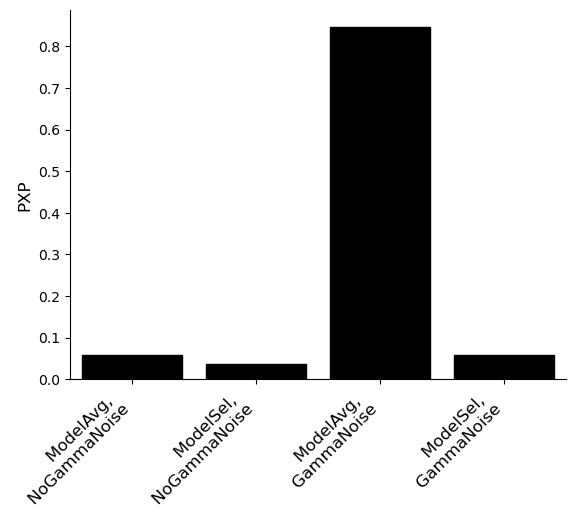

In [16]:
#make bar plots
sns.barplot(x=model_ord, y=pxp_models, color='black', edgecolor='black')
axs=plt.gca()
axs.spines[['top', 'right']].set_visible(False)
# the xlabel is tilted
plt.xticks(rotation=45, ha='right', fontsize = 12)
plt.ylabel('PXP', fontsize = 12)
plt.savefig('M:\\1confiProj\\Analysis\\model_compare.png', dpi=300, bbox_inches='tight')
plt.show()

### Make factor comparision plots

In [17]:
### load in the bayesian comparison results
import json
with open('M:\\1confiProj\\Analysis\\bms_fac_AIC.json', 'r') as f:
    bms_fac_AIC = json.load(f)  # Load the JSON as a Python dictionary

# create a dictionary for the factor names
fnames = {"Perceptual space + sensory noise source" : ["Bayes, \n GammaNoise", "Bayes, \n NoGammaNoise"], 
                "Spatial readout strategy" : ["ModelSel", "ModelAvg"]}

#flist is the keys of fnames
flist = list(fnames.keys())

In [18]:
bms_fac_AIC

[{'xp': [0.9804464557237533, 0.01955354427624663],
  'exp_r': [0.79993793022056, 0.20006206977943988],
  'cov_r': [[0.01454883981954604, -0.014548839819546034],
   [-0.014548839819546034, 0.014548839819546038]],
  'bor': 0.21992853262539402,
  'pxp': [0.8747825717113569, 0.12521742828864305]},
 {'xp': [0.01953141696815614, 0.9804685830318438],
  'exp_r': [0.20000046506467012, 0.7999995349353298],
  'cov_r': [[0.014545479912598707, -0.014545479912598707],
   [-0.014545479912598707, 0.014545479912598708]],
  'bor': 0.21951531671257593,
  'pxp': [0.12500163014283394, 0.874998369857166]}]

In [19]:
# get the AIC matrix
df_aic = pd.read_csv('M:\\1confiProj\\Analysis\\all_models_AIC.csv')
df_aic.head()

,sub_id,model_id,aic,CI_readout,est_var,Causal_readout,gamma_var
0,2,1,17203.456775,BayIntFlex,MA,Bay,0
1,2,2,17890.222258,BayIntFlex,MS,Bay,0
2,2,3,16929.307334,BayIntFlex,MA,Bay,1
3,2,4,17141.538518,BayIntFlex,MS,Bay,1
4,2,5,21679.461265,NB,MA,NonBayFixSig,0


In [20]:
model_evidences_summed = df_aic.groupby(['model_id', 'est_var', 'Causal_readout', 'gamma_var'])['aic'].sum().reset_index()
model_evidences_summed['delta_AIC'] = model_evidences_summed['aic'] - model_evidences_summed['aic'].min()

In [21]:
model_evidences_summed = model_evidences_summed.loc[model_evidences_summed.model_id.isin(np.arange(1, 5)), :]
model_evidences_summed

,model_id,est_var,Causal_readout,gamma_var,aic,delta_AIC
0,1,MA,Bay,0,132514.955653,1741.880224
1,2,MS,Bay,0,135525.737772,4752.662343
2,3,MA,Bay,1,130773.075429,0.000000
3,4,MS,Bay,1,131575.780972,802.705543


In [22]:
# new order of the models for bic plotting
#new_order = [4, 2, 8, 6, 3, 1, 7, 5]
new_order = [4, 2, 3, 1]
model_evidences_summed = model_evidences_summed.set_index('model_id').reindex(new_order).reset_index()
model_evidences_summed

,model_id,est_var,Causal_readout,gamma_var,aic,delta_AIC
0,4,MS,Bay,1,131575.780972,802.705543
1,2,MS,Bay,0,135525.737772,4752.662343
2,3,MA,Bay,1,130773.075429,0.000000
3,1,MA,Bay,0,132514.955653,1741.880224


In [23]:
aic_matrix = model_evidences_summed.delta_AIC.values.reshape(2, 2).T
aic_matrix

array([[ 802.70554262,    0.        ],
       [4752.662343  , 1741.88022418]])

In [24]:
pxp_row = bms_fac_AIC[0]['pxp'][::-1]
pxp_row

[0.12521742828864305, 0.8747825717113569]

In [25]:
pxp_col = bms_fac_AIC[1]['pxp']
pxp_col

[0.12500163014283394, 0.874998369857166]

C:\Users\wenlou\AppData\Local\Temp\ipykernel_19020\3620554169.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_top.set_yticklabels([0, 0.5, 1])
C:\Users\wenlou\AppData\Local\Temp\ipykernel_19020\3620554169.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_side.set_xticklabels([0, 0.5, 1])


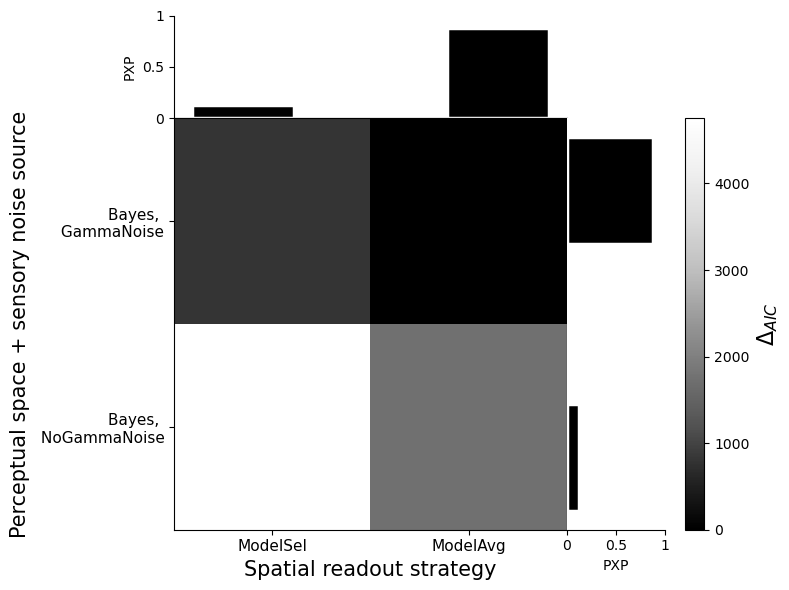

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Create layout
fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(2, 4, width_ratios=[4, 1, 0.2, 0.2], height_ratios=[1, 4],
                       wspace=0, hspace=0)

# --- Top bar plot (readout strategy) ---
ax_top = fig.add_subplot(gs[0, 0])
ax_top.bar([0.5,1.5], pxp_col, color='black', edgecolor='white',width=[0.4, 0.4], linewidth=2.5)
ax_top.set_ylim(0, 1)
ax_top.set_yticklabels([0, 0.5, 1])
ax_top.set_xticklabels([])
ax_top.set_ylabel('PXP')
ax_top.spines[['top', 'right']].set_visible(False)
# ax_top.set_title("Factor B Summary")

# --- Main heatmap ---
ax_main = fig.add_subplot(gs[1, 0])
im = ax_main.imshow(aic_matrix, cmap='Grays_r', aspect='auto')
ax_main.set_yticks([0, 1], fnames[flist[0]], fontsize=11)
ax_main.set_xticks([0,1], fnames[flist[1]], fontsize=11)
ax_main.set_xlabel(flist[1], fontsize=15)
ax_main.set_ylabel(flist[0], fontsize=15)

# Overlay BIC values
# for i in range(2):
#     for j in range(2):
#         val = aic_matrix[i, j]
#         color = 'white' if val > aic_matrix.mean() else 'black'
#         ax_main.text(j, i, str(val), ha='center', va='center', color=color)
        
# --- Side bar plot (Factor A) ---
ax_side = fig.add_subplot(gs[1, 1])
ax_side.barh([0.5,1.5], pxp_row, color='black', edgecolor='white', height=[0.4,0.4], linewidth=2.5,)
ax_side.set_xlim(0, 1)
ax_side.set_xticklabels([0, 0.5, 1])
ax_side.set_yticklabels([])
ax_side.set_yticks([])
ax_side.set_xlabel('PXP')
ax_side.spines[['top', 'right', 'left']].set_visible(False)

# ax_side.set_title("Factor A\nSummary", fontsize=10)

# --- Colorbar ---
ax_cbar = fig.add_subplot(gs[1, 3])
cbar = fig.colorbar(im, cax=ax_cbar)
cbar.set_label('$\Delta_{AIC}$', fontsize=16) 

plt.tight_layout()
plt.savefig('M:\\1confiProj\\Analysis\\factor_compare.png', dpi=300, bbox_inches='tight')
plt.show()

### Behaviour variability and confidence interval

In [8]:
# read in the behavioura file
# sub_id = 3
nbin = 10
df_all_sub = pd.DataFrame()
for sub_id in sub_lst:
    # Load the subject's behavioural data
    sub_data = np.loadtxt(os.path.join(fit_data_path, 'beh_data_sub_' + str(sub_id) + '.csv'), delimiter=',')
    df_sub = organize_sim_data(sub_data, sub_id=sub_id)
    # remove outliers
    df_sub['CISize_zscore'] = (df_sub['CISize'] - df_sub['CISize'].mean()) / df_sub['CISize'].std()
    df_sub = df_sub[df_sub.CISize_zscore.abs() < 3]  

    # mark euqal-width bin number
    df_sub['CISize_bin'] = pd.cut(df_sub['CISize_zscore'], bins=nbin, labels=False, include_lowest=True)
    df_all_sub = pd.concat([df_all_sub, df_sub], ignore_index = True)

df_all_sub.head(2)

,AudLoc,VisLoc,VisRel,blockType,RespLoc,CISize,Sources,ConfLevel,sub_id,delta_VA,VisRelLabel,bias,flipBias,abs_delta_VA,CISize_zscore,CISize_bin
0,5.0,-10.0,1.0,1.0,-4.93,4.69,1.0,20.0,2,-15.0,High,-9.93,9.93,15.0,-0.701830,3
1,-10.0,10.0,1.0,1.0,4.93,4.46,2.0,41.0,2,20.0,High,14.93,14.93,20.0,-0.787572,2


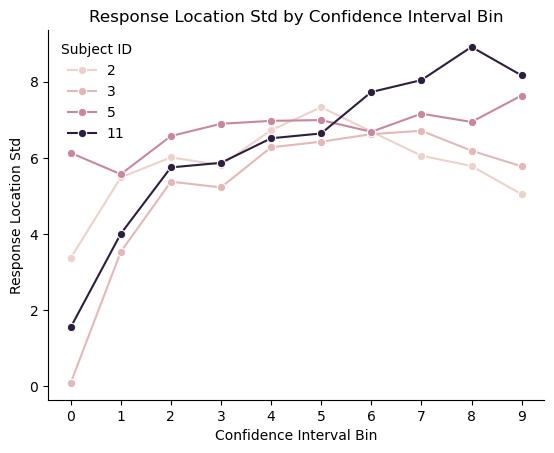

In [17]:
df_resp_var = df_all_sub[ ['RespLoc', 'sub_id', 'CISize_bin']].groupby(['sub_id', 'CISize_bin']).std().reset_index()

#plot
sns.lineplot(data=df_resp_var, x='CISize_bin', y='RespLoc', hue='sub_id', marker='o', dashes=False)
plt.xlabel('Confidence Interval Bin')    
plt.ylabel('Response Location Std')
plt.xticks(ticks=np.arange(nbin), labels=np.arange(nbin))
plt.title('Response Location Std by Confidence Interval Bin')
plt.legend(title='Subject ID', frameon=False)
axs= plt.gca()
axs.spines[['top', 'right']].set_visible(False)
plt.show()

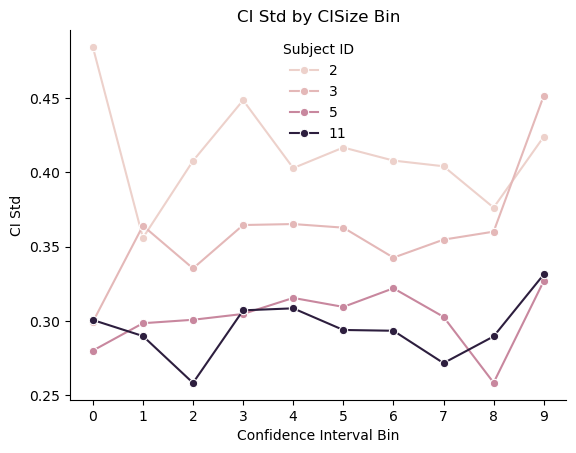

In [19]:
df_ci_var = df_all_sub[['CISize', 'sub_id', 'CISize_bin']].groupby(['sub_id', 'CISize_bin']).std().reset_index()

#plot
sns.lineplot(data=df_ci_var, x='CISize_bin', y='CISize', hue='sub_id', marker='o', dashes=False)
plt.xlabel('Confidence Interval Bin')   
plt.ylabel('CI Std')
plt.xticks(ticks=np.arange(nbin), labels=np.arange(nbin))
plt.title('CI Std by CISize Bin')
plt.legend(title='Subject ID', frameon=False)
axs= plt.gca()
axs.spines[['top', 'right']].set_visible(False)
plt.show()

In [45]:
df_sub.head()

,AudLoc,VisLoc,VisRel,blockType,RespLoc,CISize,Sources,ConfLevel,sub_id,delta_VA,VisRelLabel,bias,flipBias,abs_delta_VA,CISize_zscore,CISize_bin,ConfLevel_bin
0,5.0,-10.0,1.0,1.0,-4.93,4.69,1.0,20.0,2,-15.0,High,-9.93,9.93,15.0,-0.701830,2,1
1,-10.0,10.0,1.0,1.0,4.93,4.46,2.0,41.0,2,20.0,High,14.93,14.93,20.0,-0.787572,2,3
2,-5.0,-10.0,1.0,1.0,-5.94,5.56,1.0,39.0,2,-5.0,High,-0.94,0.94,5.0,-0.377500,2,3
3,-5.0,5.0,1.0,1.0,4.38,2.01,1.0,78.0,2,10.0,High,9.38,9.38,10.0,-1.700912,0,6
4,-5.0,-5.0,1.0,1.0,-3.82,2.91,1.0,88.0,2,0.0,High,1.18,1.18,0.0,-1.365399,1,7


### Model simulation

In [21]:
df_all = pd.read_pickle('M:\\1confiProj\\Analysis\\df_all_models_est.pkl')
df_all.head(2)

,run_id,model_id,sub_id,nll,est_params,init_params,runtime,success,k,aic
0,20250729_115040,1,2,18957.170751,"[1.3321714727949716, 8.539806365966797, 6.3120...","[1.4069522322007244, 2.1912049142031513, 3.306...",52.574208,True,14,18985.170751
1,20250729_124737,1,2,18930.047760,"[1.3374265885051844, 7.970002583228052, 6.8305...","[0.09630020017921352, 4.29648038765763, 7.0540...",56.947520,True,14,18958.047760


In [23]:
#find the best params for each model and subject. 
df_best_params = df_all[['sub_id', 'model_id', 'est_params','aic']].groupby(['sub_id', 'model_id']).apply(
    lambda x: x.loc[x['aic'].idxmin()]).reset_index(drop=True)
df_best_params.head(2)

C:\Users\wenlou\AppData\Local\Temp\ipykernel_15740\1696731559.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_best_params = df_all[['sub_id', 'model_id', 'est_params','aic']].groupby(['sub_id', 'model_id']).apply(


,sub_id,model_id,est_params,aic
0,2,1,"[1.8602777868487044, 8.10302734375, 6.54184722...",18752.297535
1,2,2,"[1.5476341864384962, 7.78220783919096, 5.72377...",19213.638911


In [35]:
#best models find the model that has the min aic for each subject
df_best_models = df_all[['sub_id', 'model_id', 'aic']].groupby(['sub_id']).apply(
    lambda x: x.loc[x['aic'].idxmin()]).reset_index(drop=True)
df_best_models

C:\Users\wenlou\AppData\Local\Temp\ipykernel_15740\1062201564.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_best_models = df_all[['sub_id', 'model_id', 'aic']].groupby(['sub_id']).apply(


,sub_id,model_id,aic
0,2.0,4.0,18548.741953
1,3.0,2.0,17433.813876
2,5.0,3.0,17755.227251
3,11.0,3.0,17593.491333


In [77]:
m_id = 2
sub_id = 2
model = ConfiModel(mid = m_id)

par_input = df_best_params.loc[(df_best_params['model_id'] == m_id) & (df_best_params['sub_id'] == sub_id), 'est_params'].values[0]
trialConds = model.getCondRep(nIntSamples=500)

dat_sim = model.run_simulation(par_input,trialConds)
df_sim = organize_sim_data(dat_sim, sub_id=sub_id)
# remove outliers
df_sim['CISize_zscore'] = (df_sim['CISize'] - df_sim['CISize'].mean()) / df_sim['CISize'].std()
df_sim = df_sim[df_sim.CISize_zscore.abs() < 3]  

# mark euqal-width bin number
df_sim['CISize_bin'] = pd.cut(df_sim['CISize_zscore'], bins=nbin, labels=False, include_lowest=True)


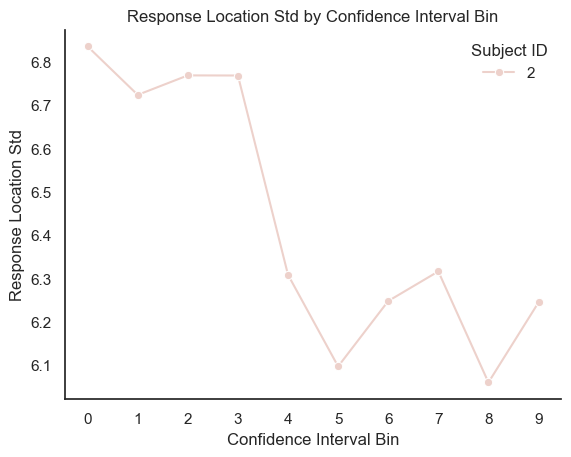

In [78]:
df_resp_var = df_sim[ ['RespLoc', 'sub_id', 'CISize_bin']].groupby(['sub_id', 'CISize_bin']).std().reset_index()

#plot
sns.lineplot(data=df_resp_var, x='CISize_bin', y='RespLoc', hue='sub_id', marker='o', dashes=False)
plt.xlabel('Confidence Interval Bin')    
plt.ylabel('Response Location Std')
plt.xticks(ticks=np.arange(nbin), labels=np.arange(nbin))
plt.title('Response Location Std by Confidence Interval Bin')
plt.legend(title='Subject ID', frameon=False)
axs= plt.gca()
axs.spines[['top', 'right']].set_visible(False)
plt.show()

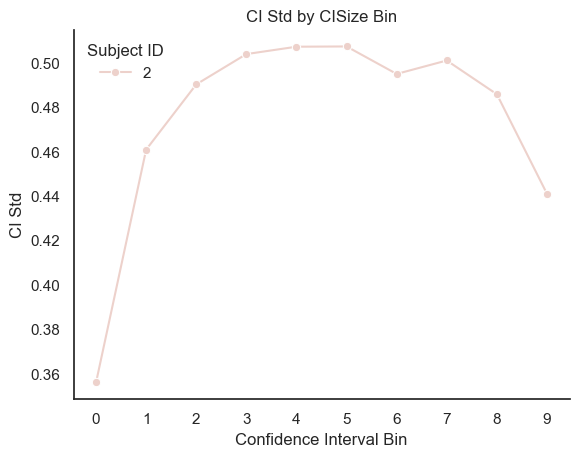

In [76]:
df_ci_var = df_sim[['CISize', 'sub_id', 'CISize_bin']].groupby(['sub_id', 'CISize_bin']).std().reset_index()

#plot
sns.lineplot(data=df_ci_var, x='CISize_bin', y='CISize', hue='sub_id', marker='o', dashes=False)
plt.xlabel('Confidence Interval Bin')   
plt.ylabel('CI Std')
plt.xticks(ticks=np.arange(nbin), labels=np.arange(nbin))
plt.title('CI Std by CISize Bin')
plt.legend(title='Subject ID', frameon=False)
axs= plt.gca()
axs.spines[['top', 'right']].set_visible(False)
plt.show()

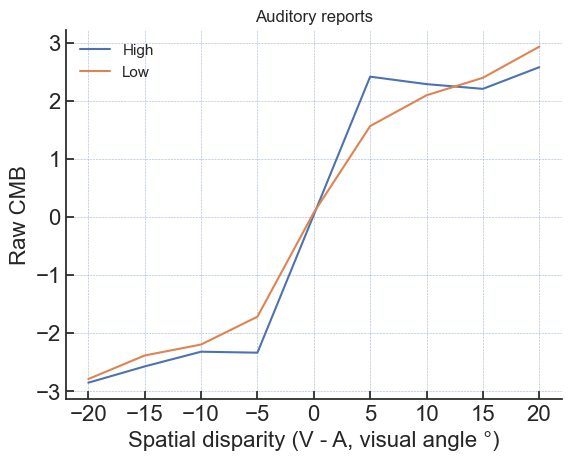

In [67]:
from utils.plot_function import *
plot_VE(df_sim,  1)

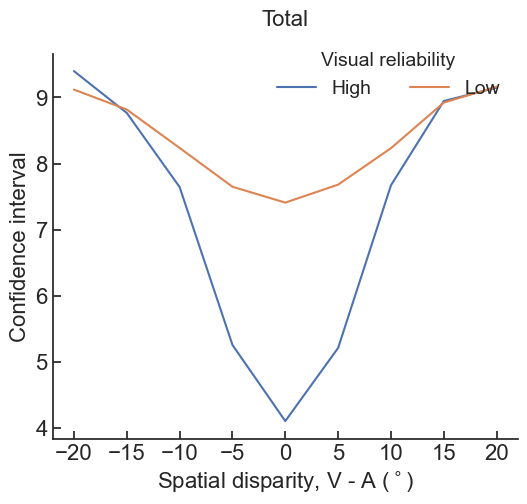

In [69]:
plot_group_pattern(df_sim, 'CISize', 'Total')

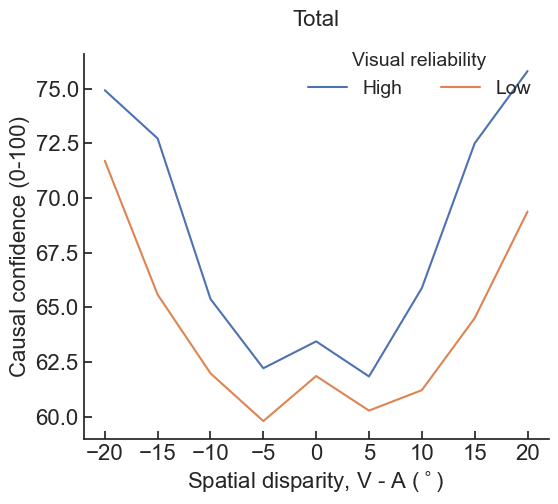

In [70]:
plot_group_pattern(df_sim, 'ConfLevel', 'Total')

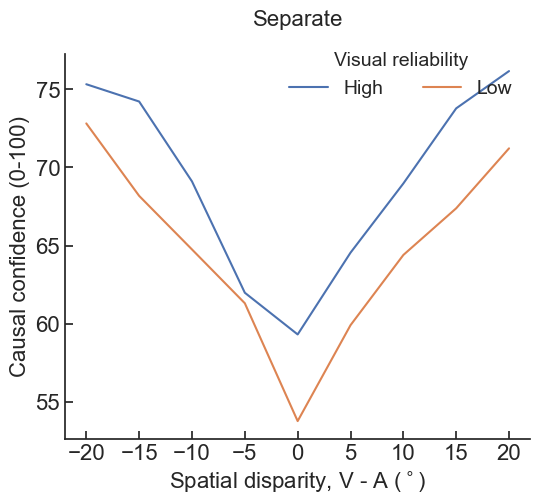

In [73]:
plot_group_pattern(df_sim, 'ConfLevel', 'Separate')

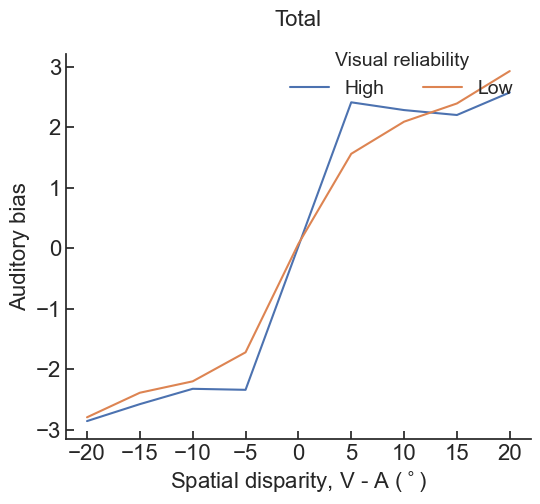

In [75]:
plot_group_pattern(df_sim, 'bias', 'Total')